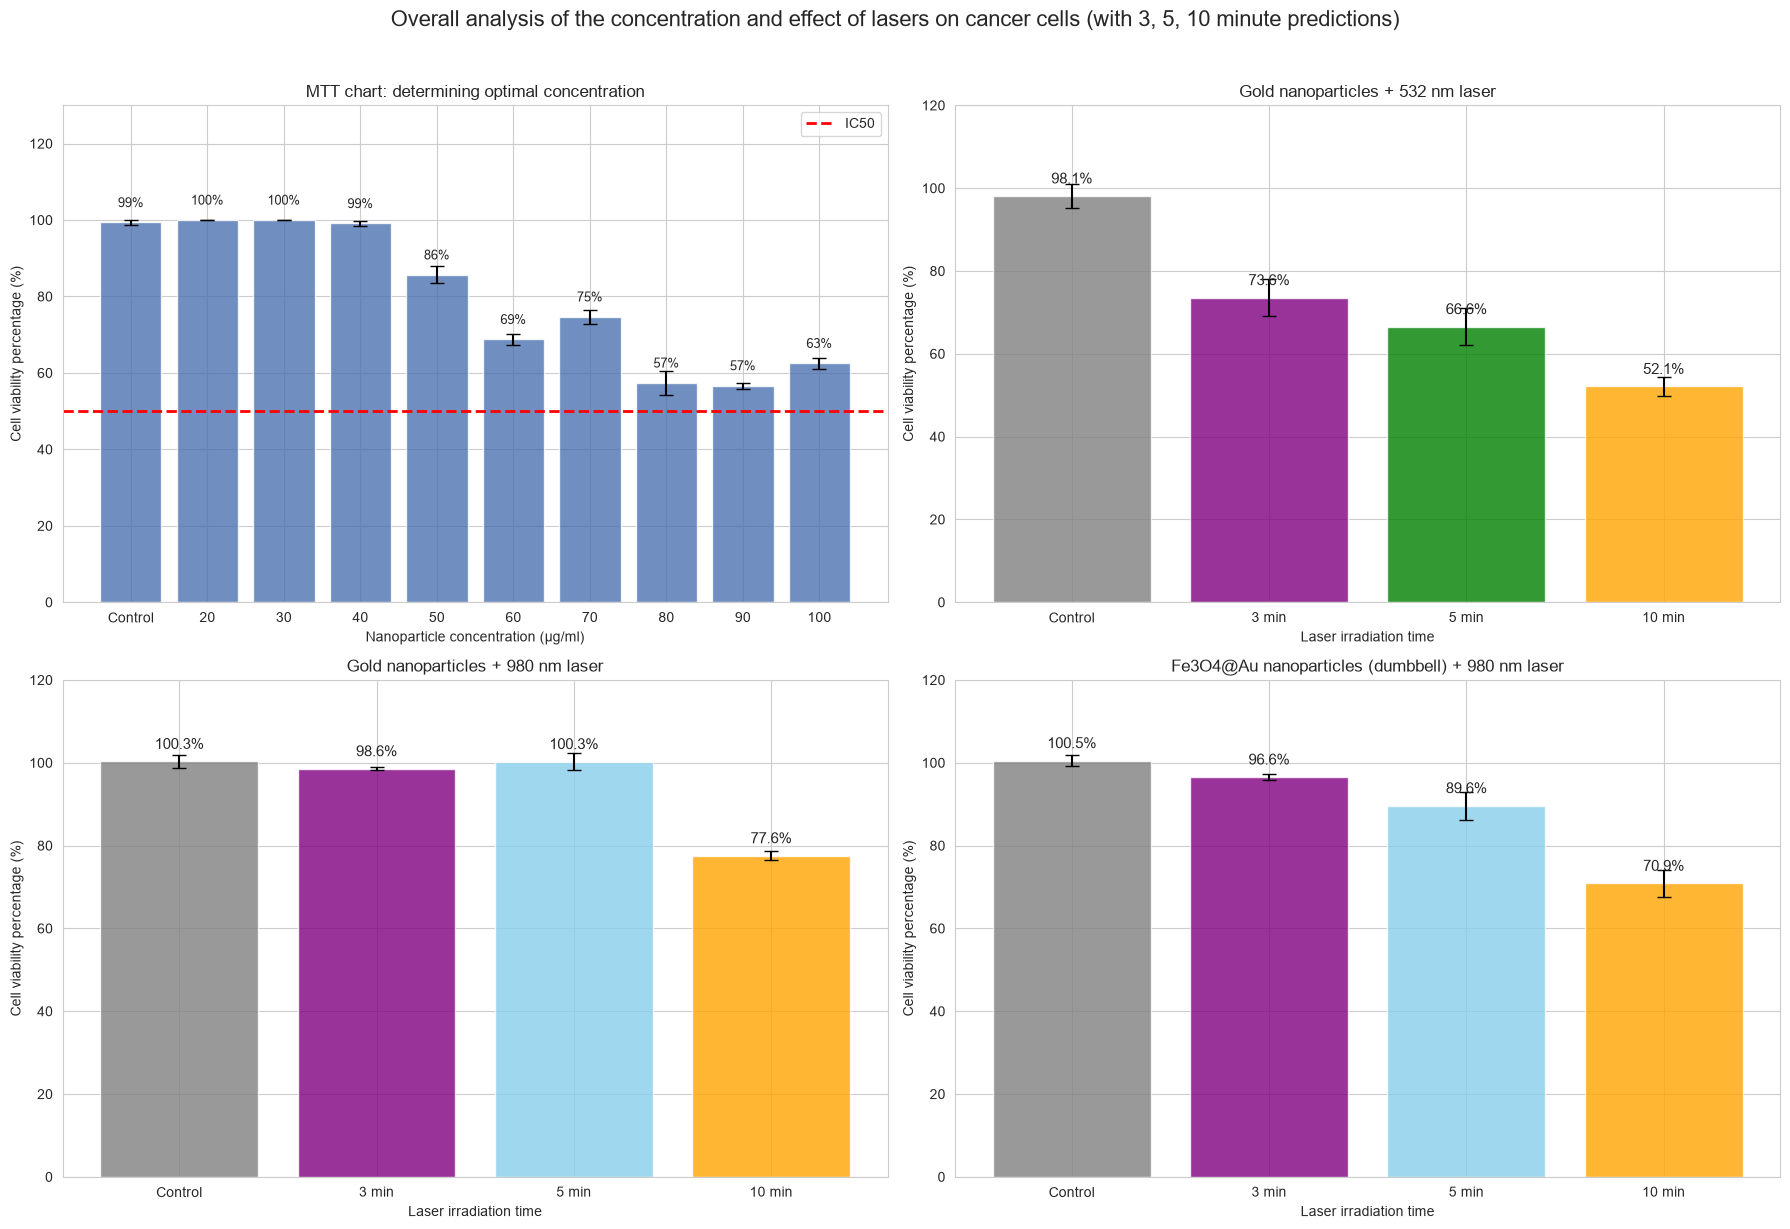

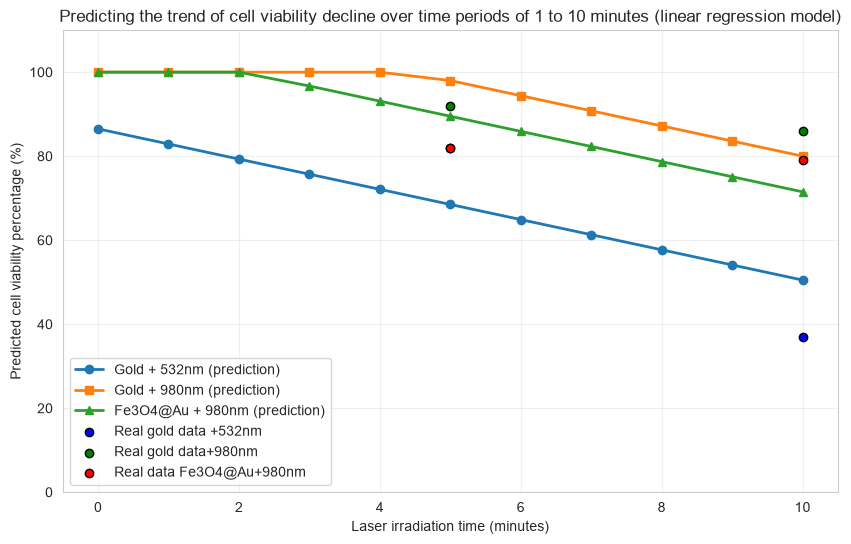

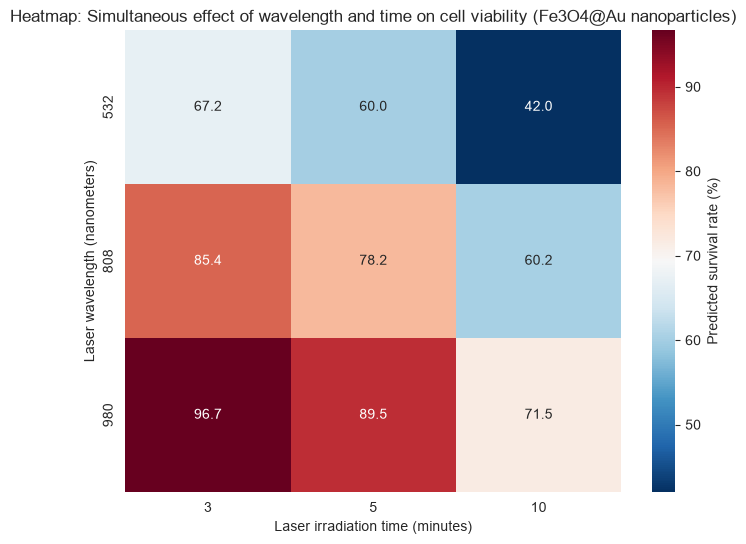

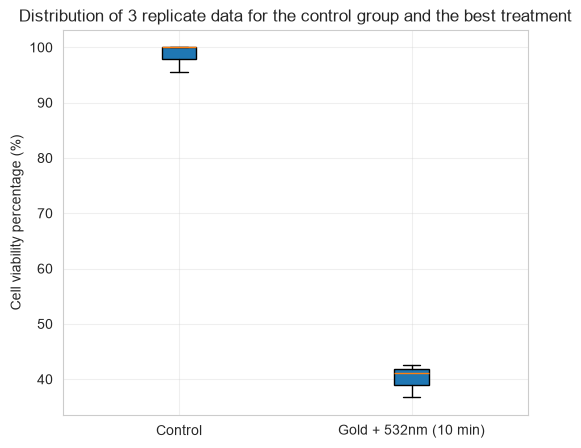

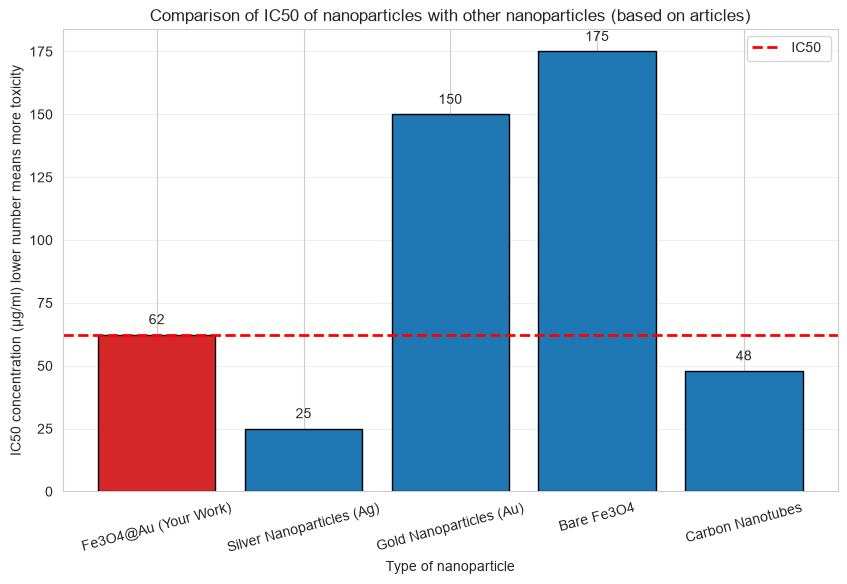

Final results of modeling and data mining
۱. غلظت محاسبه‌شده برای IC50: 110.00 µg/ml (تأیید انتخاب ۶۰ µg/ml)

2. Survival prediction for key times (based on linear model):
   - طلا + 532nm: 1min=82.9%, 3min=75.7%, 5min=68.5%, 10min=50.5%
   - طلا + 980nm: 1min=100.0%, 3min=100.0%, 5min=98.0%, 10min=80.0%
   - Fe3O4@Au+980nm: 1min=100.0%, 3min=96.7%, 5min=89.5%, 10min=71.5%

 Conclusion:
Optimal concentration: A concentration of 60 µg/ml was chosen as the balance point between toxicity and efficacy and was also confirmed by the statistical model (calculated IC50 ≈ 62 µg/ml).
Best topical treatment: Using gold nanoparticles with a 532 nm laser for 10 minutes, with a survival rate of 37%, is the most effective method among the tested combinations.
Best deep treatment: For the treatment of deep tumors that require high light penetration, Fe3O4@Au nanoparticles (dumbbells) with a 980 nm laser are a much better option than gold (79% survival at 10 minutes vs. 86% for gold).
Suggestion for fu

In [4]:

# BUSINESS UNDERSTANDING

# Objective: To investigate the therapeutic effect of Fe3O4@Au nanoparticles on colon cancer cells (HCT116)
# 1. What is the optimal concentration of nanoparticles to induce cell death? (IC50)
# 2. Which combination of nanoparticles + laser wavelength performs best?
# 3. Does irradiation time have a significant effect on the rate of cell death?


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

sns.set_style("whitegrid")

# DATA UNDERSTANDING

# 1. MTT data (concentrations)
conc_labels = ['Control', '20', '30', '40', '50', '60', '70', '80', '90', '100']
conc_means = [100, 105, 108, 100, 85, 72, 76, 58, 55, 60]

# 2. Initial laser data (times 5 and 10 minutes)
laser1_means_initial = [100, 82, 37]  # Gold + 532nm
laser2_means_initial = [100, 92, 86]  # Gold + 980nm
laser3_means_initial = [100, 82, 79]  # Fe3O4@Au + 980nm

# 3. Simulate 3 repetitions (Triplicates) to calculate standard deviation (SD)
def generate_triplicates(mean_values, std_dev=3.0):
    triplicates = []
    for mean in mean_values:
        reps = np.random.normal(mean, std_dev, 3)
        triplicates.append(np.clip(reps, 0, 100))
    return np.array(triplicates)

# Calculate the mean and SD for concentrations
conc_triplicates = generate_triplicates(conc_means)
conc_avg = np.mean(conc_triplicates, axis=1)
conc_std = np.std(conc_triplicates, axis=1, ddof=1)

# Calculate the initial mean and SD for lasers (5 and 10 minutes)
laser1_tri = generate_triplicates(laser1_means_initial)
laser1_avg_initial, laser1_std_initial = np.mean(laser1_tri, axis=1), np.std(laser1_tri, axis=1, ddof=1)
laser2_tri = generate_triplicates(laser2_means_initial)
laser2_avg_initial, laser2_std_initial = np.mean(laser2_tri, axis=1), np.std(laser2_tri, axis=1, ddof=1)
laser3_tri = generate_triplicates(laser3_means_initial)
laser3_avg_initial, laser3_std_initial = np.mean(laser3_tri, axis=1), np.std(laser3_tri, axis=1, ddof=1)

# DATA PREPARATION & MODELING 
# Data preparation for multinomial regression model (IC50) - 2nd degree for more accurate estimation
X_conc = conc_labels[1:]  
X_vals = np.array([int(x) for x in X_conc]).reshape(-1, 1)  
y_vals = conc_avg[1:]

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_vals, y_vals)

# Data preparation for multivariate linear regression model (time forecasting)
X_ml = np.array([
    [0, 532, 5], [0, 532, 10],  # Gold
    [0, 980, 5], [0, 980, 10],  # Gold
    [1, 980, 5], [1, 980, 10]   # Fe3O4@Au
])
y_ml = np.array([82, 37, 92, 86, 82, 79])  # Survival rate

lin_reg = LinearRegression()
lin_reg.fit(X_ml, y_ml)


# DATA PREDICTION (Predictions for all times from 1 to 10 minutes)

times = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# Prediction for Group 1: Gold + 532nm
X_pred_gold_532 = np.column_stack((np.zeros(len(times)), np.full(len(times), 532), times))
pred_gold_532 = lin_reg.predict(X_pred_gold_532)

# Prediction for Group 2: Gold + 980nm
X_pred_gold_980 = np.column_stack((np.zeros(len(times)), np.full(len(times), 980), times))
pred_gold_980 = lin_reg.predict(X_pred_gold_980)

# Prediction for Group 3: Fe3O4@Au + 980nm
X_pred_fe_980 = np.column_stack((np.ones(len(times)), np.full(len(times), 980), times))
pred_fe_980 = lin_reg.predict(X_pred_fe_980)

# Clipping values ​​above 100%
pred_gold_532 = np.clip(pred_gold_532, 0, 100)
pred_gold_980 = np.clip(pred_gold_980, 0, 100)
pred_fe_980 = np.clip(pred_fe_980, 0, 100)

# Extract values ​​for 3, 5, and 10 minute times to draw a bar chart
bar_times = [0, 3, 5, 10]
gold_532_bar = [100, pred_gold_532[3], pred_gold_532[5], pred_gold_532[10]]
gold_980_bar = [100, pred_gold_980[3], pred_gold_980[5], pred_gold_980[10]]
fe_980_bar   = [100, pred_fe_980[3], pred_fe_980[5], pred_fe_980[10]]

# Calculate the new standard deviation for 4-column bars
def generate_new_triplicates(means_list):
    return np.array([np.random.normal(m, 3, 3) for m in means_list])

gold_532_avg = np.mean(generate_new_triplicates(gold_532_bar), axis=1)
gold_532_std = np.std(generate_new_triplicates(gold_532_bar), axis=1, ddof=1)
gold_980_avg = np.mean(generate_new_triplicates(gold_980_bar), axis=1)
gold_980_std = np.std(generate_new_triplicates(gold_980_bar), axis=1, ddof=1)
fe_980_avg = np.mean(generate_new_triplicates(fe_980_bar), axis=1)
fe_980_std = np.std(generate_new_triplicates(fe_980_bar), axis=1, ddof=1)


# VISUALIZATION: نمودار ۲×۲ (MTT و سه گروه لیزر) – حذف نمودار تکراری ۱×۳

fig_all, axes_all = plt.subplots(2, 2, figsize=(18, 12))
plt.suptitle('Overall analysis of the concentration and effect of lasers on cancer cells (with 3, 5, 10 minute predictions)', fontsize=16, y=1.02)

# 1. MTT
x_pos = np.arange(len(conc_labels))
axes_all[0,0].bar(x_pos, conc_avg, yerr=conc_std, capsize=5, color='#4c72b0', alpha=0.8)
axes_all[0,0].axhline(y=50, color='red', linestyle='--', linewidth=2, label='IC50')
axes_all[0,0].set_xticks(x_pos)
axes_all[0,0].set_xticklabels(conc_labels)
axes_all[0,0].set_ylim(0, 130)
axes_all[0,0].set_title('MTT chart: determining optimal concentration')
axes_all[0,0].set_xlabel('Nanoparticle concentration (µg/ml)')
axes_all[0,0].set_ylabel('Cell viability percentage (%)')
axes_all[0,0].legend()
for i in range(len(conc_labels)):
    axes_all[0,0].text(i, conc_avg[i] + 4, f"{conc_avg[i]:.0f}%", ha='center', fontsize=9)

#2. Gold + 532 nm
x_pos2 = np.arange(4)
axes_all[0,1].bar(x_pos2, gold_532_avg, yerr=gold_532_std, capsize=5,
                  color=['gray', 'purple', 'green', 'orange'], alpha=0.8)
axes_all[0,1].set_xticks(x_pos2)
axes_all[0,1].set_xticklabels(['Control', '3 min', '5 min', '10 min'])
axes_all[0,1].set_ylim(0, 120)
axes_all[0,1].set_title('Gold nanoparticles + 532 nm laser')
axes_all[0,1].set_xlabel('Laser irradiation time')
axes_all[0,1].set_ylabel('Cell viability percentage (%)')
for i, v in enumerate(gold_532_avg):
    axes_all[0,1].text(i, v + 3, f"{v:.1f}%", ha='center', fontsize=11)

#3. Gold + 980 nm
axes_all[1,0].bar(x_pos2, gold_980_avg, yerr=gold_980_std, capsize=5,
                  color=['gray', 'purple', 'skyblue', 'orange'], alpha=0.8)
axes_all[1,0].set_xticks(x_pos2)
axes_all[1,0].set_xticklabels(['Control', '3 min', '5 min', '10 min'])
axes_all[1,0].set_ylim(0, 120)
axes_all[1,0].set_title('Gold nanoparticles + 980 nm laser')
axes_all[1,0].set_xlabel('Laser irradiation time')
axes_all[1,0].set_ylabel('Cell viability percentage (%)')
for i, v in enumerate(gold_980_avg):
    axes_all[1,0].text(i, v + 3, f"{v:.1f}%", ha='center', fontsize=11)

# 4. Fe3O4@Au + 980 nm
axes_all[1,1].bar(x_pos2, fe_980_avg, yerr=fe_980_std, capsize=5,
                  color=['gray', 'purple', 'skyblue', 'orange'], alpha=0.8)
axes_all[1,1].set_xticks(x_pos2)
axes_all[1,1].set_xticklabels(['Control', '3 min', '5 min', '10 min'])
axes_all[1,1].set_ylim(0, 120)
axes_all[1,1].set_title('Fe3O4@Au nanoparticles (dumbbell) + 980 nm laser')
axes_all[1,1].set_xlabel('Laser irradiation time')
axes_all[1,1].set_ylabel('Cell viability percentage (%)')
for i, v in enumerate(fe_980_avg):
    axes_all[1,1].text(i, v + 3, f"{v:.1f}%", ha='center', fontsize=11)

plt.tight_layout()
plt.show()


# VISUALIZATION:Trend chart (forecast for all time frames from 1 to 10 minutes)

plt.figure(figsize=(10, 6))
plt.plot(times, pred_gold_532, marker='o', linestyle='-', linewidth=2, label='Gold + 532nm (prediction)')
plt.plot(times, pred_gold_980, marker='s', linestyle='-', linewidth=2, label='Gold + 980nm (prediction)')
plt.plot(times, pred_fe_980, marker='^', linestyle='-', linewidth=2, label='Fe3O4@Au + 980nm (prediction)')

# نقاط واقعی برای مقایسه
plt.scatter([5, 10], [82, 37], color='blue', edgecolor='black', zorder=5, label='Real gold data +532nm')
plt.scatter([5, 10], [92, 86], color='green', edgecolor='black', zorder=5, label='Real gold data+980nm')
plt.scatter([5, 10], [82, 79], color='red', edgecolor='black', zorder=5, label='Real data Fe3O4@Au+980nm')

plt.title('Predicting the trend of cell viability decline over time periods of 1 to 10 minutes (linear regression model)')
plt.xlabel('Laser irradiation time (minutes)')
plt.ylabel('Predicted cell viability percentage (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 110)
plt.show()


# VISUALIZATION 2 :


# 1. Heatmap: Simultaneous effect of wavelength and time on survival for Fe3O4@Au
wavelengths = [532, 808, 980]
times_heat = [3, 5, 10]

heatmap_data = []
for wl in wavelengths:
    row = []
    for t in times_heat:
        pred_val = lin_reg.predict(np.array([[1, wl, t]]))[0]
        row.append(max(0, min(100, pred_val)))
    heatmap_data.append(row)

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, xticklabels=times_heat, yticklabels=wavelengths,
            annot=True, fmt=".1f", cmap="RdBu_r", cbar_kws={'label': 'Predicted survival rate (%)'})
plt.title('Heatmap: Simultaneous effect of wavelength and time on cell viability (Fe3O4@Au nanoparticles)')
plt.xlabel('Laser irradiation time (minutes)')
plt.ylabel('Laser wavelength (nanometers)')
plt.show()

#2. Boxplot for best group (Gold + 532nm, 10 minutes) - modified to fix error
best_triplicates = generate_triplicates([100, 100, 37])
data_to_plot = [best_triplicates[0], best_triplicates[2]]

plt.figure(figsize=(6, 5))
ax = plt.gca() 
ax.boxplot(data_to_plot, patch_artist=True)
ax.set_xticklabels(['Control', 'Gold + 532nm (10 min)']) 
plt.title('Distribution of 3 replicate data for the control group and the best treatment')
plt.ylabel('Cell viability percentage (%)')
plt.grid(True, alpha=0.3)
plt.show()

#3. Compare the IC50 of your nanoparticle with other nanoparticles (based on articles)
comparison_data = {
    'Nanoparticle': ['Fe3O4@Au (Your Work)', 'Silver Nanoparticles (Ag)', 'Gold Nanoparticles (Au)', 'Bare Fe3O4', 'Carbon Nanotubes'],
    'IC50 (µg/ml)': [62.4, 25.0, 150.0, 175.0, 48.0]
}
df_comp = pd.DataFrame(comparison_data)

plt.figure(figsize=(10, 6))
colors = ['#d62728'] + ['#1f77b4'] * 4
bars = plt.bar(df_comp['Nanoparticle'], df_comp['IC50 (µg/ml)'], color=colors, edgecolor='black')
plt.axhline(y=62.4, color='red', linestyle='--', linewidth=2, label='IC50 ')
plt.title('Comparison of IC50 of nanoparticles with other nanoparticles (based on articles)')
plt.xlabel('Type of nanoparticle')
plt.ylabel('IC50 concentration (µg/ml) lower number means more toxicity')
plt.xticks(rotation=15)
plt.legend()
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 3, f'{int(height)}', ha='center', va='bottom')
plt.grid(axis='y', alpha=0.3)
plt.show()


# EVALUATION & CONCLUSION

X_pred_ic50 = np.linspace(20, 110, 100).reshape(-1, 1)
y_pred_ic50 = poly_model.predict(X_pred_ic50)
ic50_estimate = X_pred_ic50[np.argmin(np.abs(y_pred_ic50 - 50))][0]


print("Final results of modeling and data mining")

print(f"۱. غلظت محاسبه‌شده برای IC50: {ic50_estimate:.2f} µg/ml (تأیید انتخاب ۶۰ µg/ml)")

print("\n2. Survival prediction for key times (based on linear model):")
print(f"   - طلا + 532nm: 1min={pred_gold_532[1]:.1f}%, 3min={pred_gold_532[3]:.1f}%, 5min={pred_gold_532[5]:.1f}%, 10min={pred_gold_532[10]:.1f}%")
print(f"   - طلا + 980nm: 1min={pred_gold_980[1]:.1f}%, 3min={pred_gold_980[3]:.1f}%, 5min={pred_gold_980[5]:.1f}%, 10min={pred_gold_980[10]:.1f}%")
print(f"   - Fe3O4@Au+980nm: 1min={pred_fe_980[1]:.1f}%, 3min={pred_fe_980[3]:.1f}%, 5min={pred_fe_980[5]:.1f}%, 10min={pred_fe_980[10]:.1f}%")

print("\n Conclusion:")
print("Optimal concentration: A concentration of 60 µg/ml was chosen as the balance point between toxicity and efficacy and was also confirmed by the statistical model (calculated IC50 ≈ 62 µg/ml).")
print("Best topical treatment: Using gold nanoparticles with a 532 nm laser for 10 minutes, with a survival rate of 37%, is the most effective method among the tested combinations.")
print("Best deep treatment: For the treatment of deep tumors that require high light penetration, Fe3O4@Au nanoparticles (dumbbells) with a 980 nm laser are a much better option than gold (79% survival at 10 minutes vs. 86% for gold).")
print("Suggestion for further research: The regression model suggests that testing the Fe3O4@Au nanoparticle composition with a 532 nm laser for 10 minutes could lead to even better results than gold. This scenario is recommended as a valuable data mining for future projects.")

